In [15]:
import os
Root = r'C:\Users\user\Desktop\THESIS\data2'
os.chdir(Root)

In [16]:
import tensorflow as tf
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, GlobalAveragePooling2D,
                                     Activation, Dropout, BatchNormalization,
                                     Flatten, Dense, AveragePooling2D)
from tensorflow.keras.optimizers import Adam
import cv2

In [18]:
data = r'C:\Users\user\Desktop\THESIS\data2'
No_breast_cancer = r'C:\Users\user\Desktop\THESIS\data2\0'
Yes_breast_cancer = r'C:\Users\user\Desktop\THESIS\data2\1'

In [19]:
dirlist=[No_breast_cancer, Yes_breast_cancer]
classes=['No', 'Yes']
filepaths=[]
labels=[]
for i,j in zip(dirlist, classes):
    filelist=os.listdir(i)
    for f in filelist:
        filepath=os.path.join (i,f)
        filepaths.append(filepath)
        labels.append(j)
print ('filepaths: ', len(filepaths), '   labels: ', len(labels))

filepaths:  4577    labels:  4577


In [20]:
import pandas as pd
Files=pd.Series(filepaths, name='filepaths')
Label=pd.Series(labels, name='labels')
df=pd.concat([Files,Label], axis=1)
df=pd.DataFrame(np.array(df).reshape(4577,2), columns = ['filepaths', 'labels'])
df.head()

,filepaths,labels
0,C:\Users\user\Desktop\THESIS\data2\0\12911_129...,No
1,C:\Users\user\Desktop\THESIS\data2\0\12911_129...,No
2,C:\Users\user\Desktop\THESIS\data2\0\12911_129...,No
3,C:\Users\user\Desktop\THESIS\data2\0\12911_129...,No
4,C:\Users\user\Desktop\THESIS\data2\0\12911_129...,No


In [21]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, train_size=0.95, random_state=0)
train_new, valid = train_test_split(train, train_size=0.90, random_state=0)

print(f"train set shape: {train_new.shape}")
print(f"test set shape: {test.shape}")
print(f"validation set shape: {valid.shape}")

train set shape: (3913, 2)
test set shape: (229, 2)
validation set shape: (435, 2)


In [22]:
print(" Distribution des classes :\n")

print("Train set:")
print(train_new['labels'].value_counts())

print("\n Validation set:")
print(valid['labels'].value_counts())

print("\n Test set:")
print(test['labels'].value_counts())


 Distribution des classes :

Train set:
labels
Yes    2056
No     1857
Name: count, dtype: int64

 Validation set:
labels
Yes    232
No     203
Name: count, dtype: int64

 Test set:
labels
Yes    129
No     100
Name: count, dtype: int64


In [23]:
train_datagen = ImageDataGenerator(rescale = 1./255.,rotation_range = 40, width_shift_range = 0.2, height_shift_range = 0.2, 
                                   shear_range = 0.2, zoom_range = 0.2, horizontal_flip = True, vertical_flip =True)
test_datagen = ImageDataGenerator(rescale = 1.0/255.)

In [24]:
train_gen = train_datagen.flow_from_dataframe(dataframe = train_new,
                                              x_col = 'filepaths', y_col ='labels',
                                              target_size = (224,224), batch_size = 32, 
                                              class_mode = 'binary', shuffle = True)
val_gen = train_datagen.flow_from_dataframe(valid, 
                                            target_size=(224,224), x_col = 'filepaths', y_col ='labels', 
                                            class_mode='binary',
                                            batch_size= 16, shuffle=True)
test_gen = test_datagen.flow_from_dataframe(test,
                                            target_size = (224,224), x_col = 'filepaths', y_col ='labels',
                                             class_mode = 'binary',
                                            batch_size = 16, shuffle = False)

Found 3913 validated image filenames belonging to 2 classes.
Found 435 validated image filenames belonging to 2 classes.
Found 229 validated image filenames belonging to 2 classes.


In [25]:
# one batch from the generator shape
images, labels = next(train_gen)  

print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


In [11]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#Charger le modèle 
base_model = keras.applications.ResNet50V2(
    weights="imagenet",
    input_shape=(224, 224, 3),
    include_top=False
)
base_model.trainable = False  #Freeze

# Construction du modèle
inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

# Compilation
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
checkpoint = ModelCheckpoint("Tumor_classifier_best.keras", save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

# train (ResNet gelé)
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

# Fine-tuning - on défreeze les 30 dernières couches
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Re-compile avec LR plus faible
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[checkpoint, early_stop],
    verbose=1
)


C:\Users\user\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4556 - loss: 0.8622
Epoch 1: val_loss improved from inf to 0.63031, saving model to Tumor_classifier_best.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 850s 6s/step - accuracy: 0.4561 - loss: 0.8615 - val_accuracy: 0.6736 - val_loss: 0.6303
Epoch 2/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6902 - loss: 0.5934
Epoch 2: val_loss improved from 0.63031 to 0.48436, saving model to Tumor_classifier_best.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 727s 6s/step - accuracy: 0.6905 - loss: 0.5931 - val_accuracy: 0.8207 - val_loss: 0.4844
Epoch 3/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7998 - loss: 0.4759
Epoch 3: val_loss improved from 0.48436 to 0.44477, saving model to Tumor_classifier_best.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 704s 6s/step - accuracy: 0.7999 - loss: 0.4758 - val_accuracy: 0.8276 - val_loss: 0.4448
Epoch 4/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8528 - loss: 0.4021
Epoch 4: val_loss impr

Epoch 25/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8961 - loss: 0.2691
Epoch 25: val_loss did not improve from 0.25497
123/123 ━━━━━━━━━━━━━━━━━━━━ 867s 7s/step - accuracy: 0.8961 - loss: 0.2691 - val_accuracy: 0.8897 - val_loss: 0.2634
Epoch 26/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8935 - loss: 0.2755
Epoch 26: val_loss did not improve from 0.25497
123/123 ━━━━━━━━━━━━━━━━━━━━ 1053s 9s/step - accuracy: 0.8935 - loss: 0.2754 - val_accuracy: 0.8966 - val_loss: 0.2764
Epoch 27/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8974 - loss: 0.2710
Epoch 27: val_loss did not improve from 0.25497
123/123 ━━━━━━━━━━━━━━━━━━━━ 888s 7s/step - accuracy: 0.8974 - loss: 0.2709 - val_accuracy: 0.8989 - val_loss: 0.2596
Epoch 28/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9049 - loss: 0.2490
Epoch 28: val_loss did not improve from 0.25497
123/123 ━━━━━━━━━━━━━━━━━━━━ 1114s 9s/step - accuracy: 0.9049 - loss: 0.2491 - val_accuracy: 0.8897 - val_los

In [24]:
# evaluation sur le test
test_loss, test_accuracy = model.evaluate(test_gen, verbose=1)

print(f"\n resultats sur le jeu de test :")
print(f"test loss     : {test_loss:.4f}")
print(f"test tccuracy : {test_accuracy*100:.2f}%")


15/15 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.9308 - loss: 0.1252

 resultats sur le jeu de test :
test loss     : 0.1383
test tccuracy : 93.01%


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Prédictions
y_true = test_gen.classes
y_pred_proba = model.predict(test_gen).ravel()
y_pred = (y_pred_proba > 0.3).astype(int)

# Rapport de classification
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['No Tumor', 'Tumor']))

15/15 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step
Classification Report:
              precision    recall  f1-score   support

    No Tumor       0.95      0.89      0.92       100
       Tumor       0.92      0.96      0.94       129

    accuracy                           0.93       229
   macro avg       0.93      0.93      0.93       229
weighted avg       0.93      0.93      0.93       229



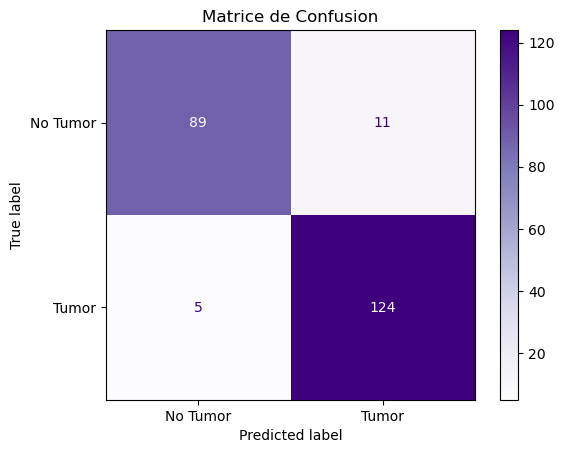

In [23]:
#matrice de confusion
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Tumor', 'Tumor'])
disp.plot(cmap='Purples')
plt.title("Matrice de Confusion")
plt.grid(False)
plt.show()

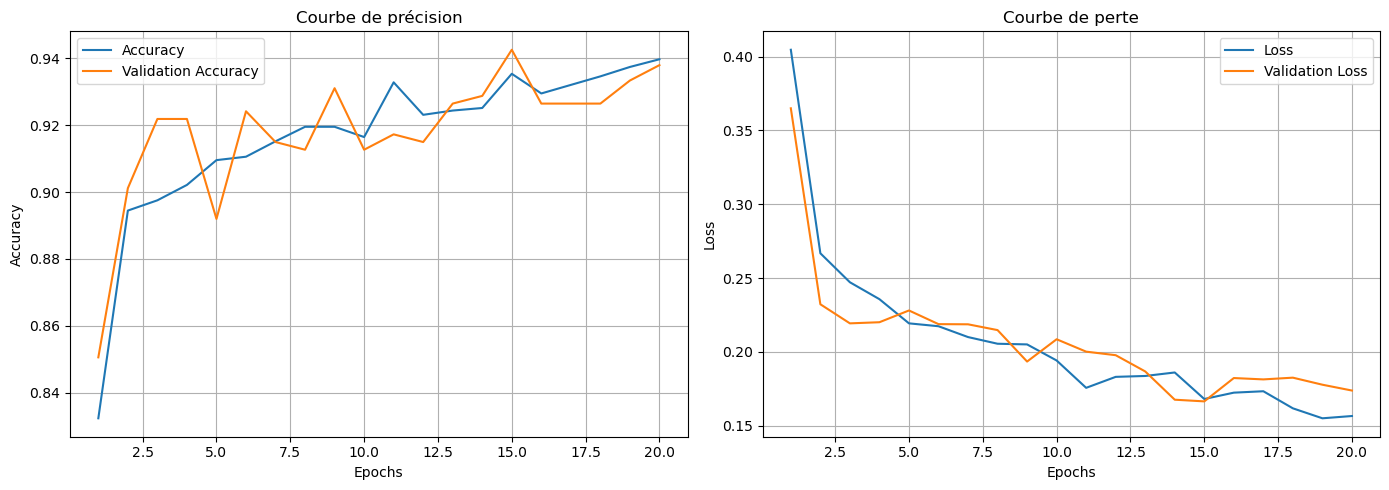

In [26]:
import matplotlib.pyplot as plt

def plot_training_curves(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # precision
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Courbe de précision')
    plt.legend()
    plt.grid(True)

    # perte
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Courbe de perte')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_curves(history_fine)


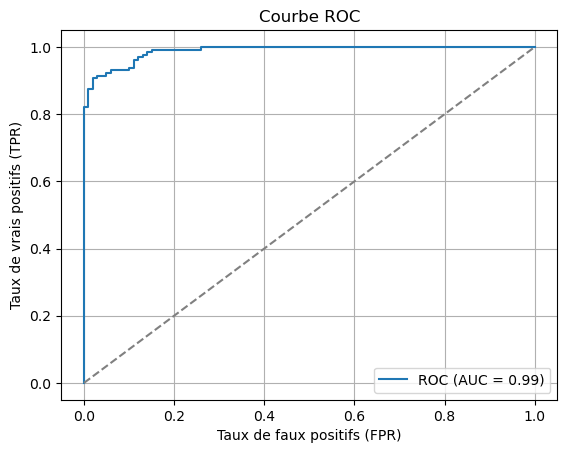

In [18]:
# Courbe ROC
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

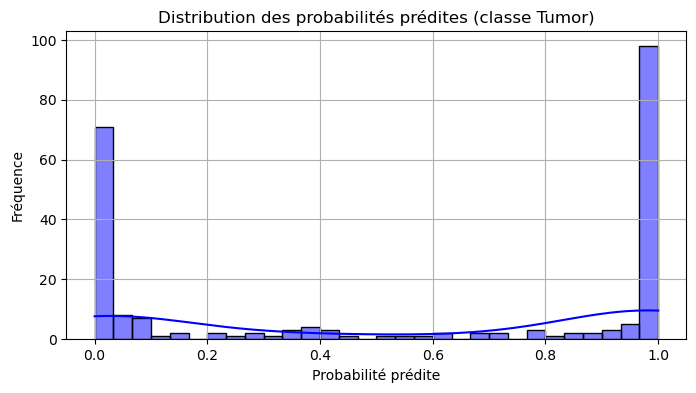

In [19]:
#histogramme des probabilités
plt.figure(figsize=(8, 4))
sns.histplot(y_pred_proba, bins=30, kde=True, color='blue')
plt.title("Distribution des probabilités prédites (classe Tumor)")
plt.xlabel("Probabilité prédite")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step


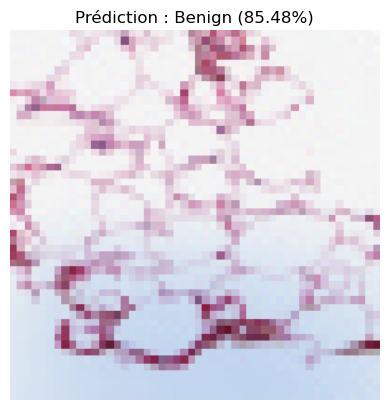

('Benign', 0.8547757714986801)

In [27]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_single_image(model, img_path, target_size=(224, 224)):
    # Charger et prétraiter l’image
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    prediction = model.predict(img_array)[0][0]
    class_name = "Malignant" if prediction >= 0.5 else "Benign"
    confidence = prediction if prediction >= 0.5 else 1 - prediction

    # Affichage
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prédiction : {class_name} ({confidence*100:.2f}%)")
    plt.show()

    return class_name, confidence

# Execution
img_path = r"D:\thesisIchrak\9083\0\9083_idx5_x251_y851_class0.png"
predict_single_image(model, img_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


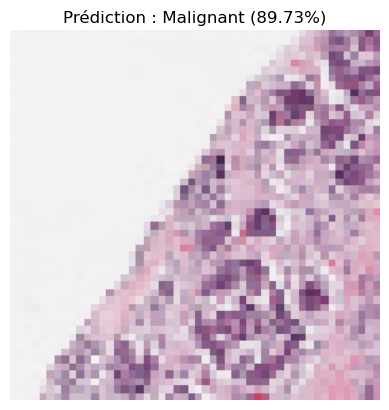

('Malignant', 0.89731795)

In [35]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_single_image(model, img_path, target_size=(224, 224)):
    # Charger et pretraiter l’image
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # prediction
    prediction = model.predict(img_array)[0][0]
    class_name = "Malignant" if prediction >= 0.5 else "Benign"
    confidence = prediction if prediction >= 0.5 else 1 - prediction

    # affichage
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prédiction : {class_name} ({confidence*100:.2f}%)")
    plt.show()

    return class_name, confidence

# execution
img_path = r"D:\thesisIchrak\9124\1\9124_idx5_x601_y601_class1.png"
predict_single_image(model, img_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


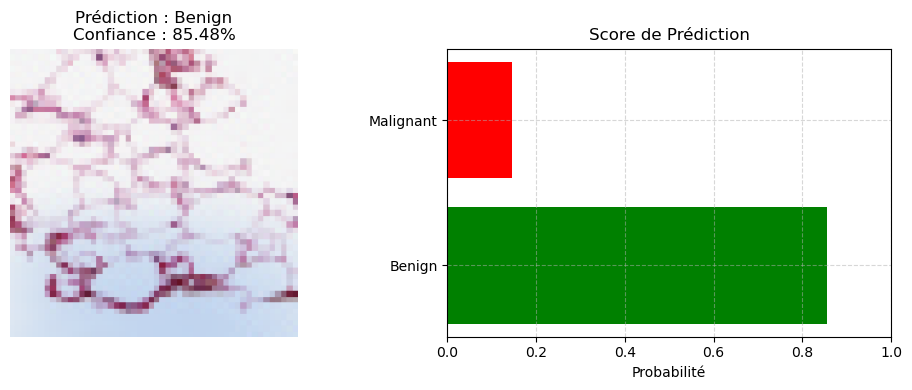

In [36]:
def predict_image_with_bar(model, img_path, target_size=(224, 224)):
    # Charger et prétraiter l’image
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prédiction
    prediction = model.predict(img_array)[0][0]
    class_name = "Malignant" if prediction >= 0.4 else "Benign"
    confidence = prediction if prediction >= 0.4 else 1 - prediction

    # Affichage : image + barre de probabilité
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    # Afficher l'image
    axs[0].imshow(img)
    axs[0].axis('off')
    axs[0].set_title(f"Prédiction : {class_name}\nConfiance : {confidence*100:.2f}%", fontsize=12)

    # Afficher la barre
    axs[1].barh(['Benign', 'Malignant'], [1 - prediction, prediction], color=['green', 'red'])
    axs[1].set_xlim(0, 1)
    axs[1].set_title("Score de Prédiction")
    axs[1].set_xlabel("Probabilité")
    axs[1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

img_path = r"D:\thesisIchrak\9083\0\9083_idx5_x251_y851_class0.png"
predict_image_with_bar(model, img_path)


In [32]:
model.save("Tumor_classifier_best.keras")

# CNN personnalisè

In [3]:
from tensorflow.keras import layers, models, optimizers

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint("CNN_classifier.keras", save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

C:\Users\user\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6710 - loss: 0.5901
Epoch 1: val_loss improved from inf to 0.42847, saving model to CNN_classifier.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 463s 4s/step - accuracy: 0.6717 - loss: 0.5895 - val_accuracy: 0.8069 - val_loss: 0.4285
Epoch 2/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8299 - loss: 0.4127
Epoch 2: val_loss improved from 0.42847 to 0.38368, saving model to CNN_classifier.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.8300 - loss: 0.4126 - val_accuracy: 0.8391 - val_loss: 0.3837
Epoch 3/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8295 - loss: 0.4121
Epoch 3: val_loss improved from 0.38368 to 0.31259, saving model to CNN_classifier.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 246s 2s/step - accuracy: 0.8296 - loss: 0.4118 - val_accuracy: 0.8805 - val_loss: 0.3126
Epoch 4/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8736 - loss: 0.3234
Epoch 4: val_loss improved from 0.31259 to 

Epoch 25/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9127 - loss: 0.2106
Epoch 25: val_loss improved from 0.18826 to 0.17828, saving model to CNN_classifier.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 461s 4s/step - accuracy: 0.9127 - loss: 0.2107 - val_accuracy: 0.9241 - val_loss: 0.1783
Epoch 26/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9208 - loss: 0.2106
Epoch 26: val_loss did not improve from 0.17828
123/123 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - accuracy: 0.9208 - loss: 0.2105 - val_accuracy: 0.9241 - val_loss: 0.1867
Epoch 27/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9193 - loss: 0.2075
Epoch 27: val_loss improved from 0.17828 to 0.17532, saving model to CNN_classifier.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 246s 2s/step - accuracy: 0.9194 - loss: 0.2075 - val_accuracy: 0.9379 - val_loss: 0.1753
Epoch 28/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9268 - loss: 0.2016
Epoch 28: val_loss improved from 0.17532 to 0.17082, saving model to CNN_c

In [17]:
results = model.evaluate(test_gen)
print(f"Test Accuracy: {results[1]*100:.2f}%")

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step - accuracy: 0.9486 - loss: 0.1408
Test Accuracy: 94.32%


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 194ms/step


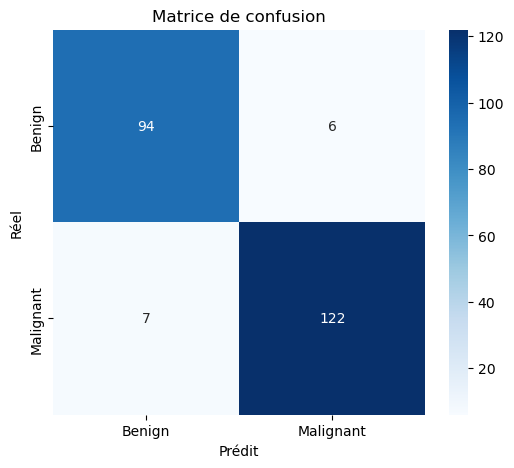

              precision    recall  f1-score   support

      Benign       0.93      0.94      0.94       100
   Malignant       0.95      0.95      0.95       129

    accuracy                           0.94       229
   macro avg       0.94      0.94      0.94       229
weighted avg       0.94      0.94      0.94       229



In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Générer les prédictions
y_pred_probs = model.predict(test_gen)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# 2. Extraire les vraies étiquettes
y_true = test_gen.classes

# 3. Afficher la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Matrice de confusion')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

# 4. Rapport de classification
print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))


In [20]:
history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    initial_epoch=30,         
    epochs=70,               
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 31/70
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9226 - loss: 0.2033
Epoch 31: val_loss did not improve from 0.17082
123/123 ━━━━━━━━━━━━━━━━━━━━ 295s 2s/step - accuracy: 0.9226 - loss: 0.2033 - val_accuracy: 0.9264 - val_loss: 0.1799
Epoch 32/70
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9172 - loss: 0.2048
Epoch 32: val_loss did not improve from 0.17082
123/123 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.9172 - loss: 0.2048 - val_accuracy: 0.9264 - val_loss: 0.1863
Epoch 33/70
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9255 - loss: 0.1895
Epoch 33: val_loss did not improve from 0.17082
123/123 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.9255 - loss: 0.1895 - val_accuracy: 0.9310 - val_loss: 0.1717
Epoch 34/70
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9165 - loss: 0.2041
Epoch 34: val_loss did not improve from 0.17082
123/123 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.9165 - loss: 0.2041 - val_accuracy: 0.9126 - val_loss:

In [21]:
results = model.evaluate(test_gen)
print(f"Test Accuracy: {results[1]*100:.2f}%")

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 183ms/step - accuracy: 0.9735 - loss: 0.1366
Test Accuracy: 96.94%


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step


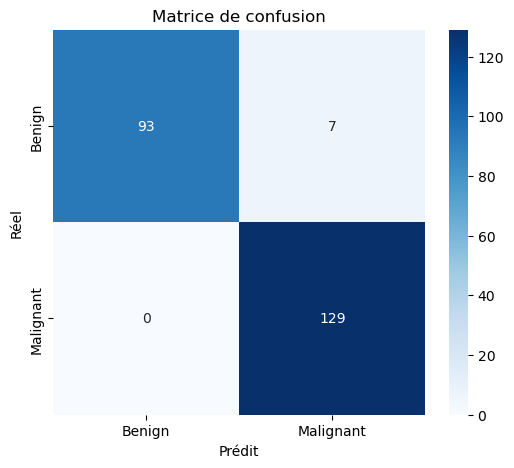

              precision    recall  f1-score   support

      Benign       1.00      0.93      0.96       100
   Malignant       0.95      1.00      0.97       129

    accuracy                           0.97       229
   macro avg       0.97      0.97      0.97       229
weighted avg       0.97      0.97      0.97       229



In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# les prédictions
y_pred_probs = model.predict(test_gen)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# extraire les vraies etiquettes
y_true = test_gen.classes

# matrice de confusion
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Matrice de confusion')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

# Rapport de classification
print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))


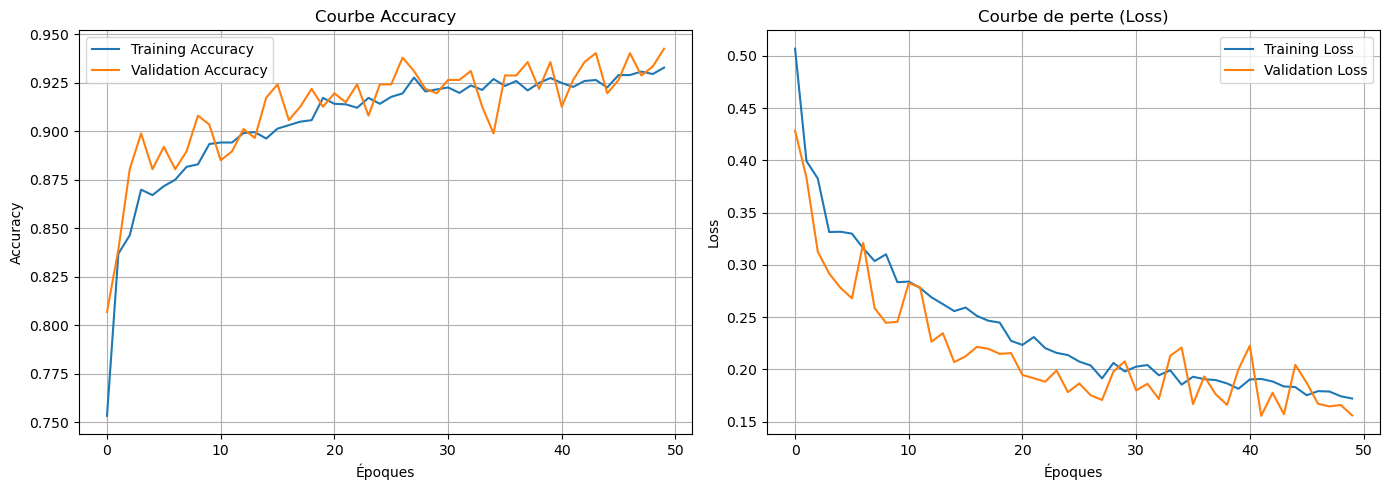

In [23]:
import matplotlib.pyplot as plt

def combine_histories(history1, history2):
    combined_history = {}
    for key in history1.history.keys():
        combined_history[key] = history1.history[key] + history2.history[key]
    return combined_history


history_all = combine_histories(history, history_fine)

# les courbes
plt.figure(figsize=(14, 5))

# Courbe de l’accuracy
plt.subplot(1, 2, 1)
plt.plot(history_all['accuracy'], label='Training Accuracy')
plt.plot(history_all['val_accuracy'], label='Validation Accuracy')
plt.title('Courbe Accuracy')
plt.xlabel('Époques')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Courbe de la loss
plt.subplot(1, 2, 2)
plt.plot(history_all['loss'], label='Training Loss')
plt.plot(history_all['val_loss'], label='Validation Loss')
plt.title('Courbe de perte (Loss)')
plt.xlabel('Époques')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step


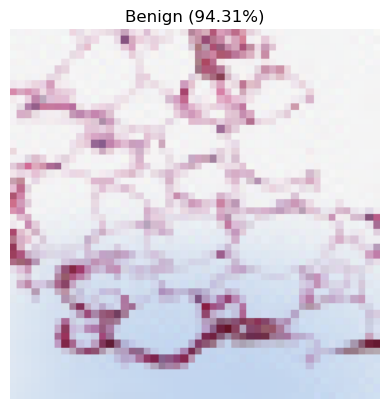

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


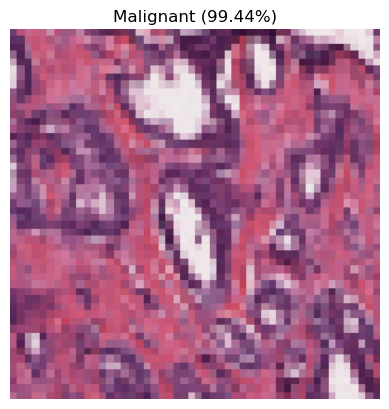

In [30]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

model = load_model("CNN_classifier.keras")

# fonction de prediction
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]
    label = "Malignant" if prediction >= 0.5 else "Benign"
    confidence = prediction if prediction >= 0.5 else 1 - prediction

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{label} ({confidence*100:.2f}%)")
    plt.show()

img_path1 = r"D:\thesisIchrak\9083\0\9083_idx5_x251_y851_class0.png"
img_path2 = r"D:\thesisIchrak\12822\1\12822_idx5_x501_y51_class1.png"

predict_image(img_path1)
predict_image(img_path2)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step


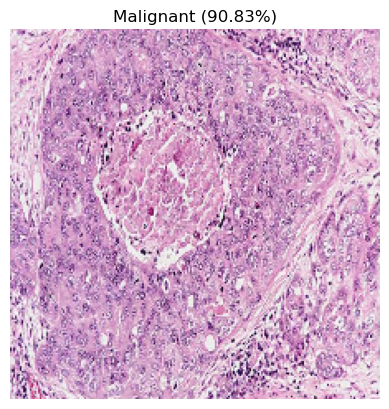

In [36]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

model = load_model("CNN_classifier.keras")

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0  
    img_array = np.expand_dims(img_array, axis=0)  

    prediction = model.predict(img_array)[0][0]
    label = "Malignant" if prediction >= 0.5 else "Benign"
    confidence = prediction if prediction >= 0.5 else 1 - prediction

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{label} ({confidence*100:.2f}%)")
    plt.show()

img_path = r"C:\Users\user\Desktop\memoire\pict\56test.jpg" #from google

predict_image(img_path)

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step


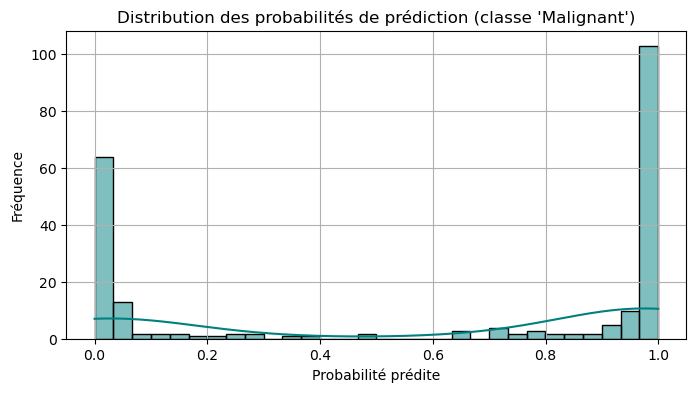

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

#les probabilités de prédiction 
y_pred_proba = model.predict(test_gen).flatten()

plt.figure(figsize=(8, 4))
sns.histplot(y_pred_proba, bins=30, kde=True, color='teal')
plt.title("Distribution des probabilités de prédiction (classe 'Malignant')")
plt.xlabel("Probabilité prédite")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 184ms/step


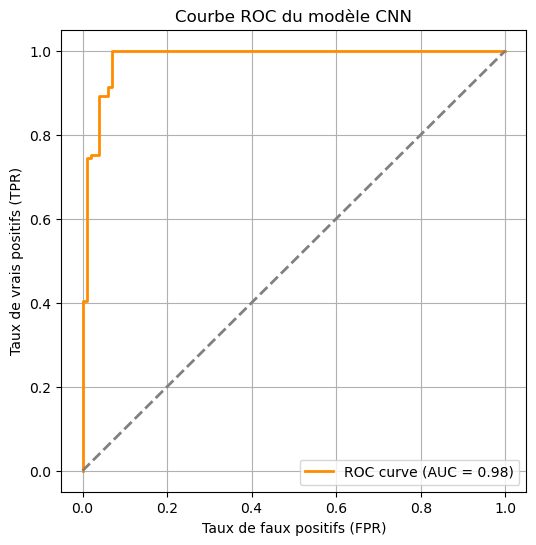

In [40]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Obtenir les vraies étiquettes
y_true = test_gen.classes

# Prédictions du modèle 
y_pred_proba = model.predict(test_gen).flatten()

# Calcul des courbes ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Affichage
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title("Courbe ROC du modèle CNN")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [43]:
model.save("CNN_classifier.keras")

# log loss 

évaluer  modèle sur un autre dossier 

In [4]:
from tensorflow.keras.models import load_model

model_path = r"C:\Users\user\Desktop\THESIS\data2\CNN_classifier.keras"
model = load_model(model_path)

print("Modèle chargé avec succès.")


Modèle chargé avec succès.


In [5]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import log_loss, classification_report

In [6]:
other_data_path = r"D:\thesisIchrak\12910"
no_path = os.path.join(other_data_path, "0")
yes_path = os.path.join(other_data_path, "1")

filepaths = []
labels = []

for folder, label in [(no_path, "Benign"), (yes_path, "Malignant")]:
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        filepaths.append(fpath)
        labels.append(label)

df_other = pd.DataFrame({"filepaths": filepaths, "labels": labels})


In [7]:
datagen = ImageDataGenerator(rescale=1./255)

other_gen = datagen.flow_from_dataframe(
    df_other,
    x_col='filepaths',
    y_col='labels',
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

Found 213 validated image filenames belonging to 2 classes.


In [8]:
# Prédictions
y_true = other_gen.classes
y_pred_prob = model.predict(other_gen).flatten()

# Log Loss
logloss_value = log_loss(y_true, y_pred_prob)
print(f"Log Loss: {logloss_value:.4f}")

# Classification Report
y_pred_class = (y_pred_prob >= 0.5).astype(int)
print("\n Classification Report:\n")
print(classification_report(y_true, y_pred_class, target_names=["Benign", "Malignant"]))


C:\Users\user\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 373ms/step
Log Loss: 0.8211

 Classification Report:

              precision    recall  f1-score   support

      Benign       0.97      0.46      0.62        81
   Malignant       0.75      0.99      0.85       132

    accuracy                           0.79       213
   macro avg       0.86      0.72      0.74       213
weighted avg       0.83      0.79      0.77       213



14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 197ms/step


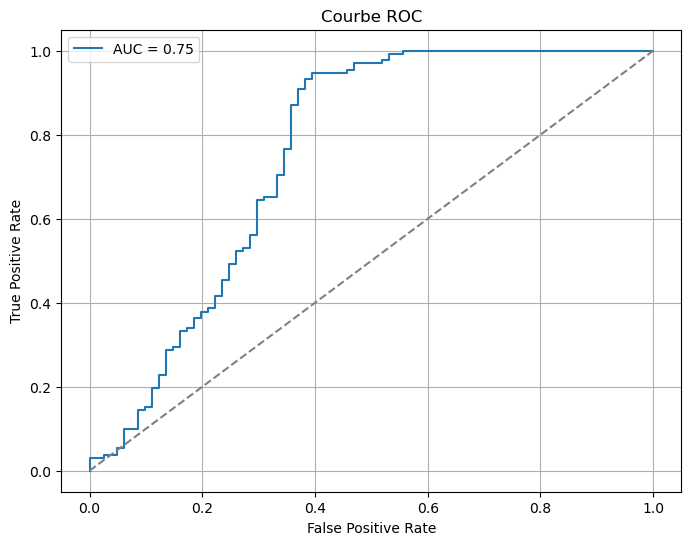


--- Rapport de classification avec seuil 0.4 ---

              precision    recall  f1-score   support

      Benign       1.00      0.43      0.60        81
   Malignant       0.74      1.00      0.85       132

    accuracy                           0.78       213
   macro avg       0.87      0.72      0.73       213
weighted avg       0.84      0.78      0.76       213



In [11]:
from sklearn.metrics import roc_curve, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Étape 1 : Prédictions (probabilités) sur le dataset externe
y_true = other_gen.classes  # vraies classes (0 ou 1)
y_scores = model.predict(other_gen).flatten()  # scores prédits entre 0 et 1

# Étape 2 : ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
auc = roc_auc_score(y_true, y_scores)

# Tracer la courbe ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.title("Courbe ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# Étape 3 : Tester un seuil ajusté (par ex. 0.6)
threshold = 0.4
y_pred_adjusted = (y_scores >= threshold).astype(int)

# Nouveau rapport de classification
print("\n--- Rapport de classification avec seuil 0.4 ---\n")
print(classification_report(y_true, y_pred_adjusted, target_names=["Benign", "Malignant"]))

# DenseNet121

In [26]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

#  modèle DenseNet121 sans les couches fully connected
base_model = DenseNet121(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))
base_model.trainable = False  # Ne pas entraîner les couches pré-entraînées

# Ajouter les couches de classification personnalisées
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=predictions)
model.summary()

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

checkpoint = ModelCheckpoint("DenseNet121_classifier.keras", save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=[checkpoint, early_stop],
    verbose=1
)


Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_2              │ (None, 230, 230, 3)       │               0 │ input_layer_1[0][0]        │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,408 │ zero_padding2d_2[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_3              │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1 (MaxPooling2D)          │ (None, 56, 56, 64)        │               0 │ zero_padding2d_3[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_bn             │ (None, 56, 56, 64)        │             256 │ pool1[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_0_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 128)       │           8,192 │ conv2_block1_0_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 128)       │             512 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 128)       │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 32)        │          36,864 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_concat           │ (None, 56, 56, 96)        │               0 │ pool1[0][0],               │
│ (Concatenate)                 │                           │               

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

C:\Users\user\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


C:\Users\user\anaconda3\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_988']. Received: the structure of inputs=*
  warnings.warn(


123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5031 - loss: 0.8197
Epoch 1: val_loss improved from inf to 0.61347, saving model to DenseNet121_classifier.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 575s 4s/step - accuracy: 0.5034 - loss: 0.8193 - val_accuracy: 0.6897 - val_loss: 0.6135
Epoch 2/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5983 - loss: 0.6861
Epoch 2: val_loss improved from 0.61347 to 0.53778, saving model to DenseNet121_classifier.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 444s 4s/step - accuracy: 0.5985 - loss: 0.6859 - val_accuracy: 0.8046 - val_loss: 0.5378
Epoch 3/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6992 - loss: 0.5828
Epoch 3: val_loss improved from 0.53778 to 0.48635, saving model to DenseNet121_classifier.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 368s 3s/step - accuracy: 0.6992 - loss: 0.5827 - val_accuracy: 0.8253 - val_loss: 0.4863
Epoch 4/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7326 - loss: 0.5372
Epoch 4: val_loss improved fro

123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8887 - loss: 0.2989
Epoch 49: val_loss did not improve from 0.22949
123/123 ━━━━━━━━━━━━━━━━━━━━ 342s 3s/step - accuracy: 0.8887 - loss: 0.2988 - val_accuracy: 0.9126 - val_loss: 0.2545
Epoch 50/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8890 - loss: 0.2806
Epoch 50: val_loss did not improve from 0.22949
123/123 ━━━━━━━━━━━━━━━━━━━━ 281s 2s/step - accuracy: 0.8890 - loss: 0.2807 - val_accuracy: 0.8966 - val_loss: 0.2577


In [27]:
from tensorflow.keras.models import load_model

model = load_model("DenseNet121_classifier.keras")

In [28]:
print("\nÉvaluation sur le jeu de test :")
test_loss, test_accuracy = model.evaluate(test_gen)
print(f"Test Accuracy : {test_accuracy:.4f} | Test Loss : {test_loss:.4f}")


Évaluation sur le jeu de test :
15/15 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.9375 - loss: 0.2322
Test Accuracy : 0.9301 | Test Loss : 0.2506


15/15 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step

Rapport de classification :
              precision    recall  f1-score   support

      Benign       0.93      0.91      0.92       100
   Malignant       0.93      0.95      0.94       129

    accuracy                           0.93       229
   macro avg       0.93      0.93      0.93       229
weighted avg       0.93      0.93      0.93       229



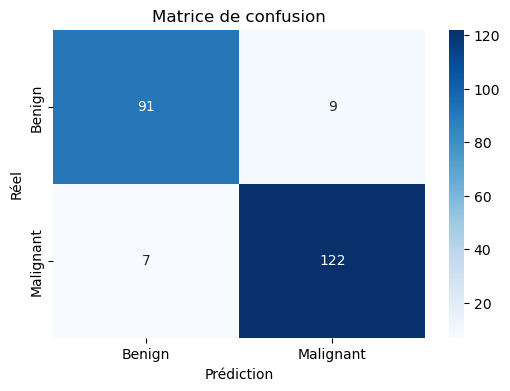

In [29]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = test_gen.classes
y_pred_probs = model.predict(test_gen)
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()

print("\nRapport de classification :")
print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Réel")
plt.show()


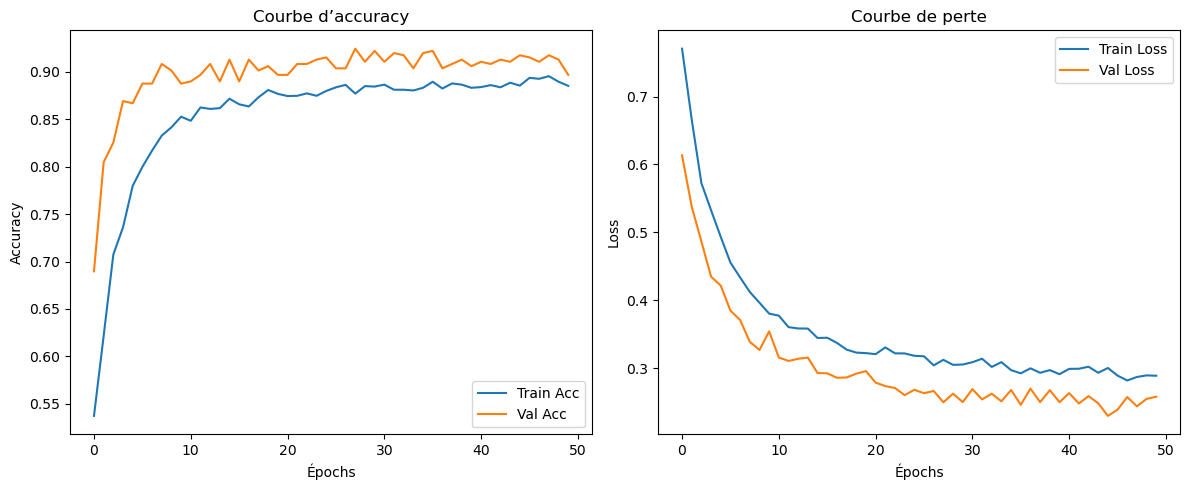

In [30]:
plt.figure(figsize=(12, 5))

# Courbe Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Courbe d’accuracy")
plt.xlabel("Épochs")
plt.ylabel("Accuracy")
plt.legend()

# Courbe Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Courbe de perte")
plt.xlabel("Épochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()
